In [11]:
import mne
import numpy as np
import matplotlib.pyplot as plt

In [2]:
epochs = mne.read_epochs('/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-1501/sub-1501_eeg-epo.fif')

Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-1501/sub-1501_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
375 matching events found
No baseline correction applied
0 projection items activated


In [4]:
epochs_A = epochs['A']
epochs_V = epochs['V']
epochs_AV = epochs['AV']

In [22]:
epochs.times

array([-0.5       , -0.49804688, -0.49609375, -0.49414062, -0.4921875 ,
       -0.49023438, -0.48828125, -0.48632812, -0.484375  , -0.48242188,
       -0.48046875, -0.47851562, -0.4765625 , -0.47460938, -0.47265625,
       -0.47070312, -0.46875   , -0.46679688, -0.46484375, -0.46289062,
       -0.4609375 , -0.45898438, -0.45703125, -0.45507812, -0.453125  ,
       -0.45117188, -0.44921875, -0.44726562, -0.4453125 , -0.44335938,
       -0.44140625, -0.43945312, -0.4375    , -0.43554688, -0.43359375,
       -0.43164062, -0.4296875 , -0.42773438, -0.42578125, -0.42382812,
       -0.421875  , -0.41992188, -0.41796875, -0.41601562, -0.4140625 ,
       -0.41210938, -0.41015625, -0.40820312, -0.40625   , -0.40429688,
       -0.40234375, -0.40039062, -0.3984375 , -0.39648438, -0.39453125,
       -0.39257812, -0.390625  , -0.38867188, -0.38671875, -0.38476562,
       -0.3828125 , -0.38085938, -0.37890625, -0.37695312, -0.375     ,
       -0.37304688, -0.37109375, -0.36914062, -0.3671875 , -0.36

In [23]:
times2save = epochs.times * 1000 
print(times2save.shape) # 這會顯示你的時間點數量

(667,)


In [ ]:
freqs = np.logspace(*np.log10([1, 50]), num=200)
n_cycles = freqs / 2.0  # different number of cycle per frequency
power = epochs_A.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    decim=3,
)

In [25]:
power.data

array([[[3.42205024e-08, 3.34845990e-08, 3.24206252e-08, ...,
         7.96440191e-08, 8.08914722e-08, 8.13299916e-08],
        [3.41064182e-08, 3.33787491e-08, 3.23243962e-08, ...,
         7.93126563e-08, 8.05511720e-08, 8.09839469e-08],
        [3.39887842e-08, 3.32695885e-08, 3.22251376e-08, ...,
         7.89712249e-08, 8.02005374e-08, 8.06273995e-08],
        ...,
        [1.32520011e-10, 1.36449967e-10, 1.39561345e-10, ...,
         2.09084561e-10, 2.06716509e-10, 2.02815502e-10],
        [1.27196394e-10, 1.31029031e-10, 1.34086047e-10, ...,
         1.98682429e-10, 1.96401452e-10, 1.92690932e-10],
        [1.22403112e-10, 1.26169600e-10, 1.29198695e-10, ...,
         1.89164940e-10, 1.86989269e-10, 1.83463971e-10]],

       [[2.39961355e-08, 2.35345731e-08, 2.28516204e-08, ...,
         4.82045842e-08, 4.87302086e-08, 4.87854324e-08],
        [2.39154132e-08, 2.34592767e-08, 2.27826855e-08, ...,
         4.80001095e-08, 4.85214683e-08, 4.85743275e-08],
        [2.38321827e-08, 

Applying baseline correction (mode: logratio)


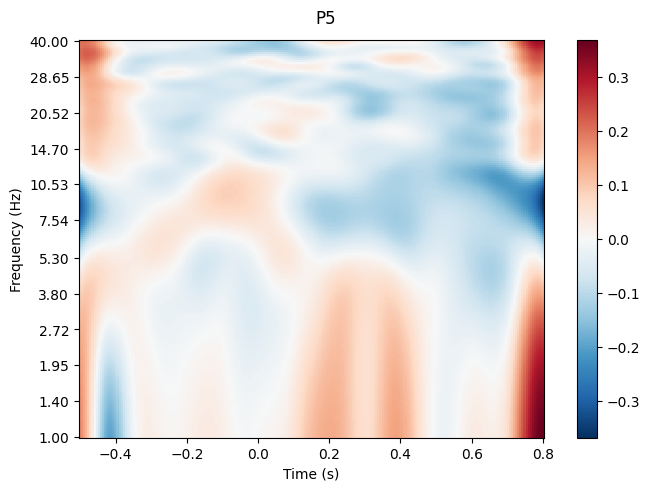

[<Figure size 640x480 with 2 Axes>]

In [9]:
#power.plot_topo(baseline=(-0.5, 0), mode="logratio", title="Average power")
power.plot(picks=[20], baseline=(-0.5, 0), mode="logratio", title=power.ch_names[20])

Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)


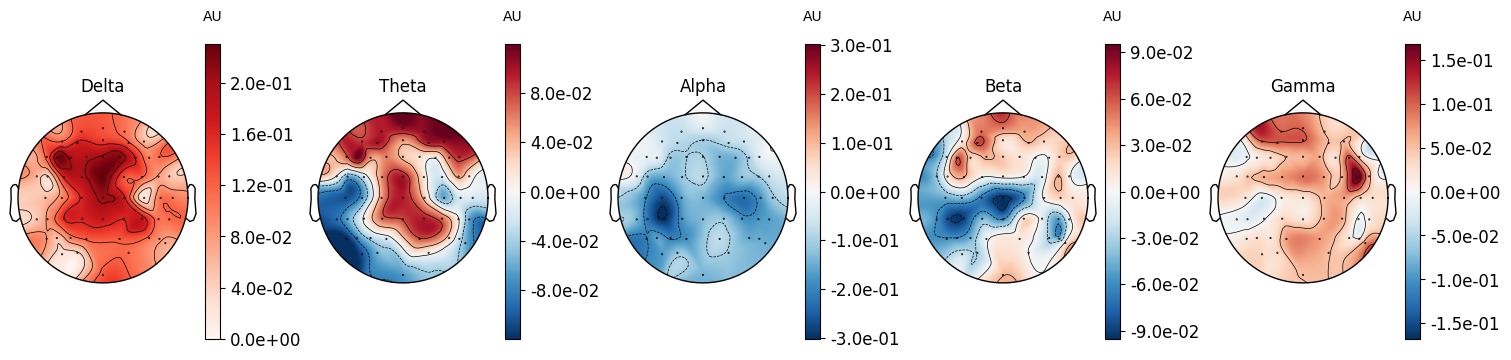

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5), layout="constrained")
topomap_kw = dict(
    ch_type="eeg", tmin=0.5, tmax=1.5, baseline=(-0.5, 0), mode="logratio", show=False
)
plot_dict = dict(Delta=dict(fmin=1, fmax=4), Theta=dict(fmin=4, fmax=8), Alpha=dict(fmin=8, fmax=12), Beta=dict(fmin=13, fmax=30), Gamma=dict(fmin=30, fmax=40))
for ax, (title, fmin_fmax) in zip(axes, plot_dict.items()):
    power.plot_topomap(**fmin_fmax, axes=ax, **topomap_kw)
    ax.set_title(title)

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


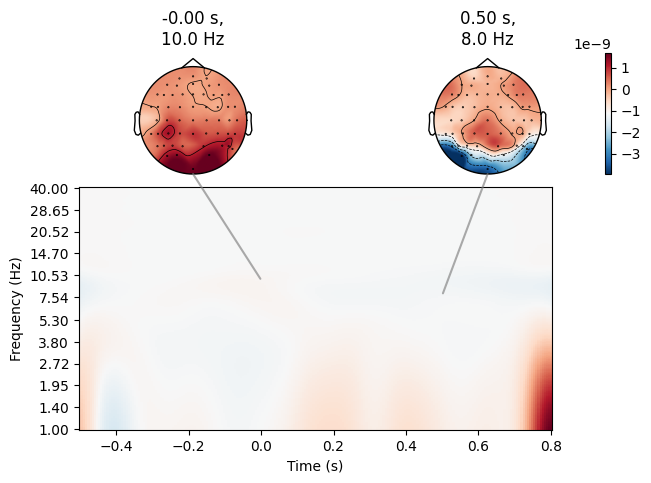

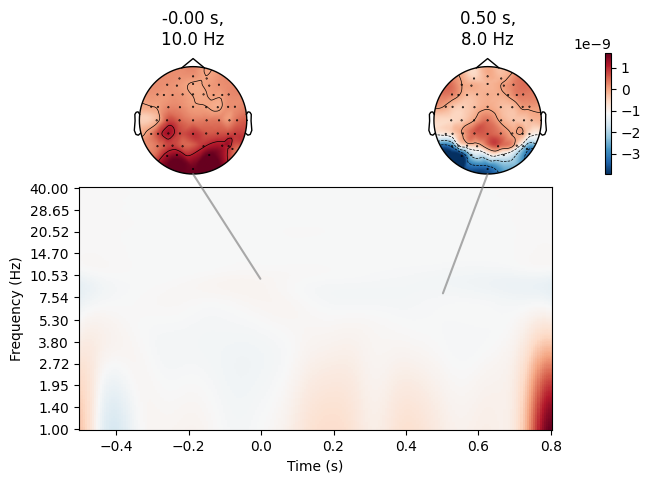

In [19]:
power.plot_joint(
    baseline=(-0.5, 0), mode="mean", tmin=-0.5, tmax=2, timefreqs=[(0, 10), (0.5, 8)]
)

In [ ]:
# Time-frequency analysis for each quartile 
freqs = np.linspace(*np.array([2, 40]), num=200) #num = step / bin allows a precision of the frequency resolution
n_cycles = freqs / 2  # different number of cycle per frequency
    
# Total power for each quartile
power_A = mne.time_frequency.tfr_morlet(epochs_A, freqs=freqs, n_cycles=n_cycles, use_fft=True,
                            output = 'complex', return_itc=False, decim=1, n_jobs=1, average=False)
# Compute Time-Frequency Representation (TFR) using Morlet wavelets, which operates on Epochs or Evoked objects instead of NumPy arrays.
# https://mne.tools/stable/generated/mne.time_frequency.tfr_morlet.html